In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('gurgaon_properties_cleaned_v2.csv')

In [4]:
df.head()

,property_type,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,godrej,1.30,sector 79,8269.0,1572.0,Super Built up area 1572(146.04 sq.m.),2,2,3,3.0,North-East,New Property,1572.0,NaN,NaN,1,0,0,0,0,1,49.0
1,flat,shree vardhman victoria,1.63,sector 70,8358.0,1950.0,Super Built up area 1950(181.16 sq.m.)Carpet area: 1161 sq.ft. (107.86 sq.m.),3,5,3,12.0,East,Relatively New,1950.0,NaN,1161.0,0,1,0,0,0,1,43.0
2,flat,tulip monsella,7.40,sector 53,33198.0,2229.0,Carpet area: 2229 (207.08 sq.m.),4,4,3,21.0,NaN,Under Construction,NaN,NaN,2229.0,0,0,0,0,0,1,35.0
3,flat,raheja sampada,0.65,sector 92,4744.0,1370.0,Super Built up area 1370(127.28 sq.m.),3,2,3,6.0,North-East,Relatively New,1370.0,NaN,NaN,0,0,0,0,0,1,49.0
4,flat,signature andour heights,0.60,sector 71,10000.0,600.0,Super Built up area 600(55.74 sq.m.)Carpet area: 514 sq.ft. (47.75 sq.m.),2,2,1,5.0,South-West,Relatively New,600.0,NaN,514.0,0,0,0,1,0,1,59.0


In [5]:
df.shape

(3863, 23)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3863 entries, 0 to 3862
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3863 non-null   object 
 1   society              3342 non-null   object 
 2   price                3862 non-null   float64
 3   sector               3863 non-null   object 
 4   price_per_sqft       3862 non-null   float64
 5   area                 3862 non-null   float64
 6   areaWithType         3863 non-null   object 
 7   bedRoom              3863 non-null   int64  
 8   bathroom             3863 non-null   int64  
 9   balcony              3863 non-null   object 
 10  floorNum             3842 non-null   float64
 11  facing               2727 non-null   object 
 12  agePossession        3863 non-null   object 
 13  super_built_up_area  1926 non-null   float64
 14  built_up_area        1774 non-null   float64
 15  carpet_area          1975 non-null   f

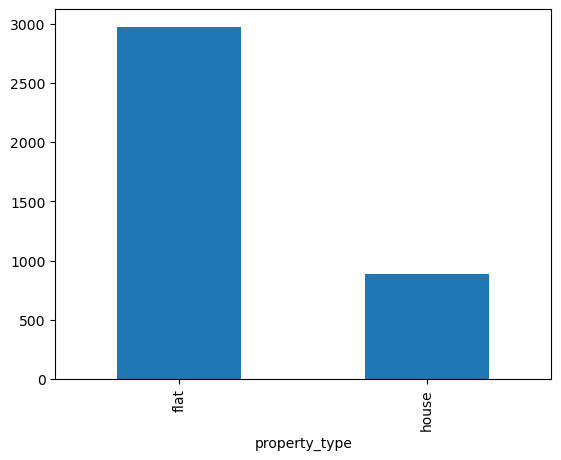

In [7]:
# property_type
df['property_type'].value_counts().plot(kind = 'bar')
plt.show()

Observation :
* There are nearly 80% of the properties are flats and 20% of the properties are houses
* No null values

In [8]:
# society
df['society'].value_counts().count()

696

In [9]:
df['society'].value_counts()

society
tulip violet                                         75
ss the leaf                                          74
shapoorji pallonji joyville gurugram                 45
dlf new town heights                                 42
signature global park                                37
shree vardhman victoria                              35
smart world orchard                                  33
smart world gems                                     33
emaar mgf emerald floors premier                     32
paras dews                                           31
dlf the ultima                                       31
dlf regal gardens                                    30
m3m woodshire                                        30
shree vardhman flora                                 29
la vida by tata housing                              28
godrej nature plus                                   27
signature global solera                              27
emaar gurgaon greens                    

In [10]:
df[df['society'] != 'independent']['society'].value_counts(normalize=True).cumsum().head(75)

society
tulip violet                            0.022442
ss the leaf                             0.044584
shapoorji pallonji joyville gurugram    0.058049
dlf new town heights                    0.070616
signature global park                   0.081688
shree vardhman victoria                 0.092160
smart world orchard                     0.102035
smart world gems                        0.111909
emaar mgf emerald floors premier        0.121484
paras dews                              0.130760
dlf the ultima                          0.140036
dlf regal gardens                       0.149013
m3m woodshire                           0.157989
shree vardhman flora                    0.166667
la vida by tata housing                 0.175045
godrej nature plus                      0.183124
signature global solera                 0.191203
emaar gurgaon greens                    0.198683
bptp terra                              0.206164
eldeco accolade                         0.213345
tata primant

In [11]:
society_counts = df['society'].value_counts()

frequency_bins = {
    'Very High (>100)' : (society_counts > 100).sum(),
    'High (50 - 100)' : ((society_counts >= 50 ) & (society_counts <= 100)).sum(),
    'Average (10 - 49)' : ((society_counts >= 10 ) & (society_counts <= 49)).sum(),
    "Low (2-9)": ((society_counts > 1) & (society_counts < 10)).sum(),
    "Very Low (1)": (society_counts == 1).sum()
}


In [12]:
frequency_bins

{'Very High (>100)': 0,
 'High (50 - 100)': 2,
 'Average (10 - 49)': 97,
 'Low (2-9)': 295,
 'Very Low (1)': 302}

<Axes: xlabel='society'>

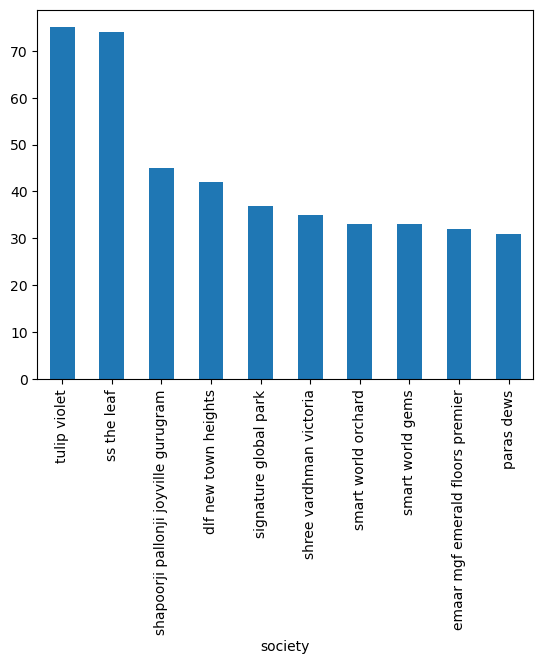

In [13]:
# top 10 socities
df[df['society'] != 'independent']['society'].value_counts().head(10).plot(kind='bar')

In [14]:
df['society'].isnull().sum()

521

In [15]:
society_null_index = df[df['society'].isnull()].index

Observation:
* There are 696 categories
* 50% of the properties present in top 75 societies
* Maximum no. of properties in the society is 100
* 2 societies contains properties between 50 - 100
* 97 societies have properties between 10 - 49
* 295 societies have properties between 1 - 9
* 302 societies have properties exactly 1

<h2> Price </h2>

In [16]:
df['price'].value_counts()

price
1.25     83
0.90     68
1.50     68
1.10     68
1.20     66
1.40     64
1.30     62
0.95     60
2.00     60
1.00     53
1.60     50
0.75     49
1.35     47
1.75     47
1.70     45
0.50     44
0.80     44
1.55     43
1.90     43
1.65     42
0.85     42
1.80     41
1.15     38
2.50     38
2.20     37
3.50     37
0.40     37
0.60     37
1.45     35
0.65     34
0.45     33
2.10     33
0.70     32
1.05     31
0.55     29
2.25     29
0.35     29
3.00     27
1.85     25
5.00     25
2.35     24
5.50     23
6.50     23
2.40     22
2.30     21
6.00     21
0.30     20
4.00     19
3.25     19
4.50     18
0.32     17
0.82     17
0.42     17
2.65     17
3.40     17
2.80     17
7.00     16
0.92     16
2.60     16
0.28     16
2.15     16
0.38     16
1.95     15
0.78     15
8.00     15
2.45     15
1.38     15
0.88     15
2.75     14
2.70     14
0.36     14
8.50     14
4.25     14
1.32     13
0.26     13
6.75     13
0.87     12
1.42     12
2.55     12
0.98     12
0.99     12
0.56     12
2.95     1

In [17]:
df['price'].describe()

count    3862.000000
mean        2.490067
std         2.930200
min         0.070000
25%         0.920000
50%         1.500000
75%         2.700000
max        31.500000
Name: price, dtype: float64

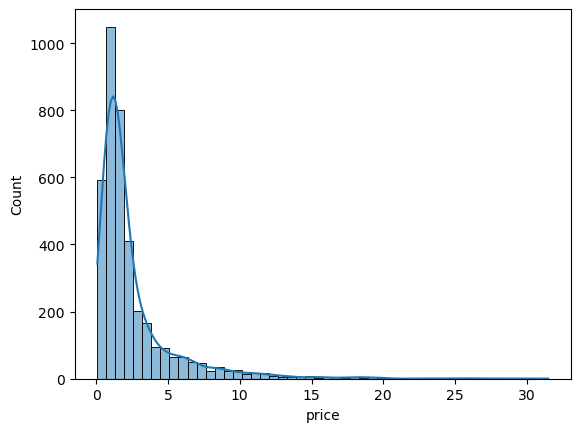

In [18]:
sns.histplot(data = df, x = 'price', bins = 50, kde = True, cbar = True)
plt.show()

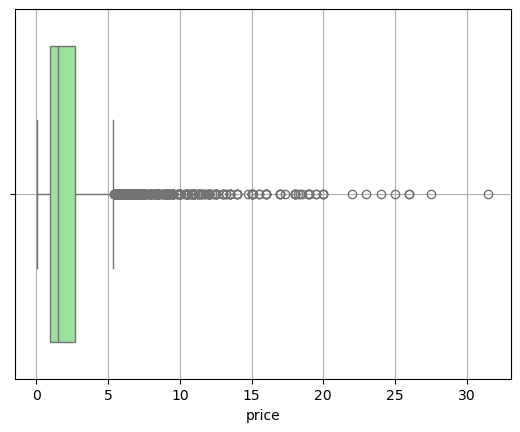

In [19]:
sns.boxplot(data = df, x = 'price', color = 'lightgreen')
plt.grid()
plt.show()

In [20]:
df['price'].isnull().sum()

1

Observation
* There are total no. of 3861 not-null values
* Mean => 2.49
* Median => 1.50
* Maximum property price is 31.5 crore
* Interquartile range between 92 lakhs to 2.7 crore

In [21]:
# Skewness and Kurtosis
skewness = df['price'].skew()
kurtosis = df['price'].kurt()

In [22]:
print(skewness, kurtosis)

3.3277820249623478 15.4614440592123


<Axes: xlabel='price'>

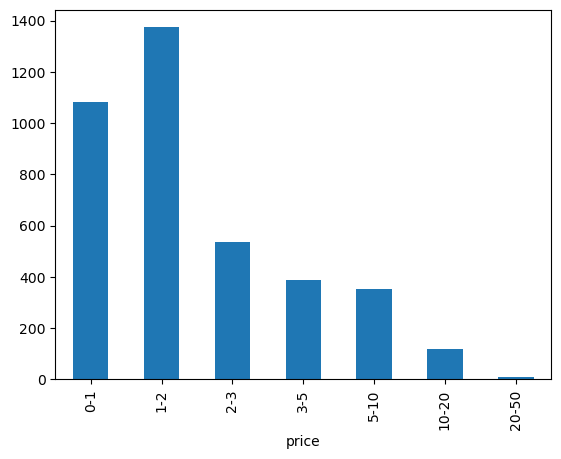

In [52]:
# price binning
bins = [0, 1, 2, 3, 5, 10, 20, 50]
bin_labels = ["0-1", "1-2", "2-3", "3-5", "5-10", "10-20", "20-50"]
pd.cut(df['price'], bins=bins, labels=bin_labels, right=False).value_counts().sort_index().plot(kind='bar')

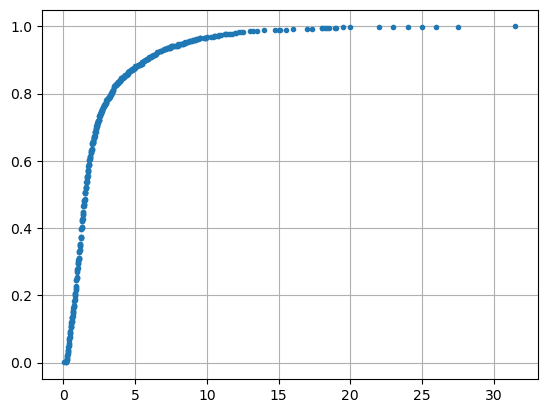

In [53]:
# ecdf plot
ecdf = df['price'].value_counts().sort_index().cumsum() / len(df['price'])
plt.plot(ecdf.index, ecdf, marker='.', linestyle='none')
plt.grid()

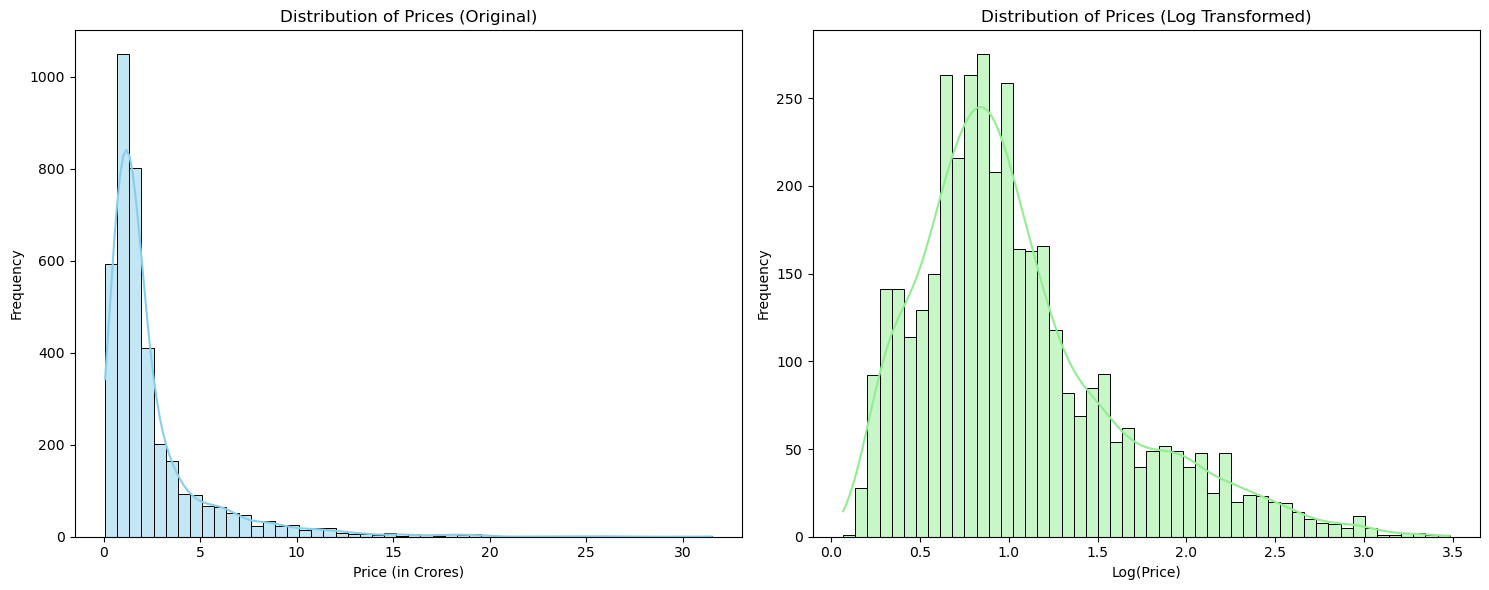

In [54]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.histplot(df['price'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['price']), kde=True, bins=50, color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

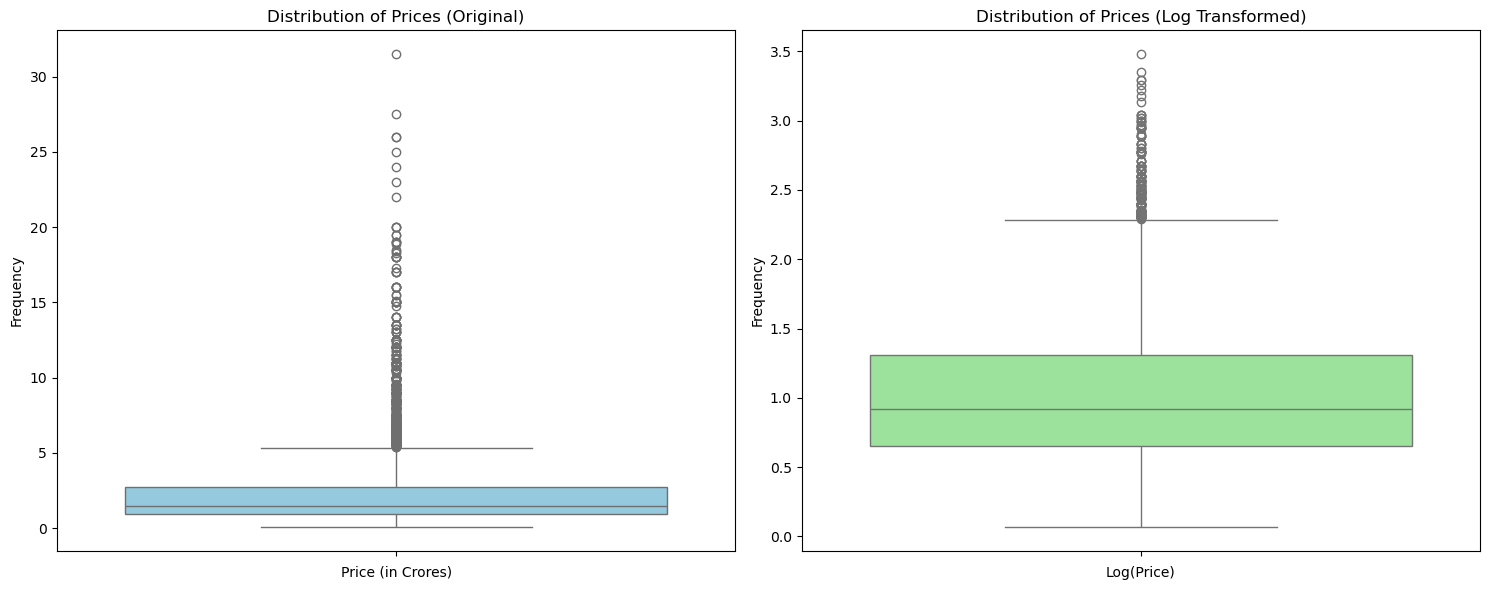

In [55]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.boxplot(df['price'], color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.boxplot(np.log1p(df['price']), color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

<h2> Sector </h2>

In [38]:
df['sector'].value_counts()

sector
sohna                    163
sector 102               113
sector 85                110
sector 92                105
sector 69                 94
sector 90                 91
sector 65                 90
sector 81                 89
sector 109                88
sector 79                 80
sector 104                70
sector 83                 69
sector 37d                68
sector 48                 67
sector 86                 67
sector 25                 65
sector 50                 64
sector 56                 62
sector 107                60
sector 108                58
sector 23                 58
sector 95                 57
sector 89                 56
sector 49                 54
sector 70a                54
sector 70                 53
sector 43                 53
sector 37c                53
sector-33 sohna           51
sector 84                 51
sector 26                 50
sector 103                49
sector 67                 48
sector 61                 44
sector 

In [35]:
df['sector'].value_counts().head(25).sum() / df.shape[0] * 100

50.53067564069376

<Axes: xlabel='sector'>

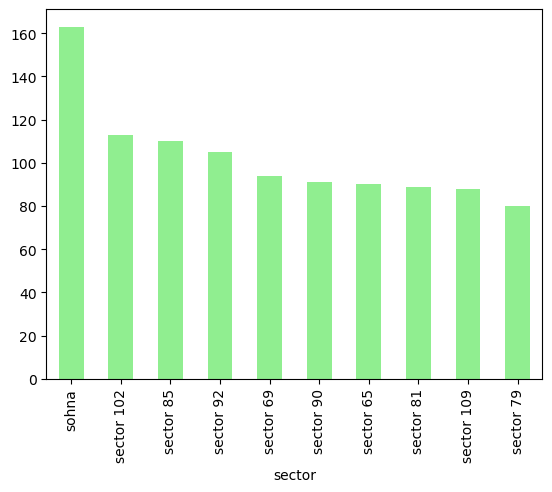

In [44]:
df['sector'].value_counts().head(10).plot(kind = 'bar', color = 'lightgreen')

In [45]:
df['sector'].isnull().sum()

0

In [46]:
sector_counts = df['sector'].value_counts()

In [47]:
sector_frequency_bins = {
    "Very High (>100)": (sector_counts > 100).sum(),
    "High (50-100)": ((sector_counts >= 50) & (sector_counts <= 100)).sum(),
    "Average (10-49)": ((sector_counts >= 10) & (sector_counts < 50)).sum(),
    "Low (2-9)": ((sector_counts > 1) & (sector_counts < 10)).sum(),
    "Very Low (1)": (sector_counts == 1).sum()
}

In [49]:
sector_frequency_bins

{'Very High (>100)': 4,
 'High (50-100)': 27,
 'Average (10-49)': 62,
 'Low (2-9)': 55,
 'Very Low (1)': 1}

Observations 
* 25% of the properties present in the top 10 sectors
* no null values
* Very High (>100): 4
* High (50-100)': 27
* Average (10-49)': 62
* Low (2-9)': 55
* Very Low (1)': 1

<h2> Price per Sqrt </h2>

In [50]:
df['price_per_sqft'].value_counts()

price_per_sqft
10000.0     28
8000.0      20
12500.0     18
5000.0      18
11111.0     15
22222.0     14
6666.0      14
7500.0      14
8333.0      13
6000.0      12
33333.0     11
12000.0     11
9000.0       9
7000.0       9
8461.0       9
8928.0       7
7407.0       7
4444.0       7
11428.0      6
31481.0      6
6500.0       6
26667.0      6
8888.0       6
23333.0      6
37037.0      6
11500.0      6
26235.0      6
4666.0       6
5500.0       6
9230.0       6
6578.0       6
5600.0       5
23148.0      5
12222.0      5
13333.0      5
7641.0       5
8500.0       5
13750.0      5
16000.0      5
30556.0      5
8784.0       5
15000.0      5
8571.0       5
13000.0      5
9210.0       5
5556.0       5
10714.0      5
5384.0       5
11666.0      5
14242.0      5
15384.0      5
4615.0       5
8205.0       5
9444.0       5
7692.0       5
7812.0       4
24691.0      4
16666.0      4
14000.0      4
6735.0       4
32407.0      4
14418.0      4
10416.0      4
7750.0       4
10383.0      4
8787.0    

In [51]:
df['price_per_sqft'].describe()

count      3862.000000
mean      13850.998964
std       23078.397256
min           4.000000
25%        6801.250000
50%        9000.000000
75%       13750.000000
max      600000.000000
Name: price_per_sqft, dtype: float64

<Axes: xlabel='price_per_sqft', ylabel='Count'>

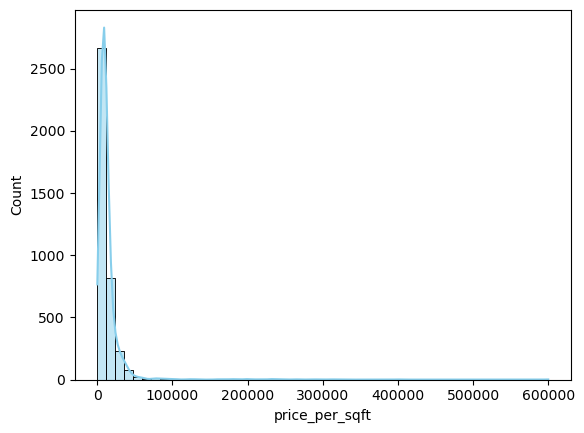

In [58]:
sns.histplot(df['price_per_sqft'], bins=50, color='skyblue', kde=True)

In [59]:
df['price_per_sqft'].isnull().sum()

1

Observations
* Mean price is 13850
* 1 null value
* Std is high
* Max value is too high , there is inconsistency in data

<h2> bedrooms </h2>

In [65]:
df['bedRoom'].value_counts()

bedRoom
3     1570
2     1011
4      688
5      203
1      135
6       79
9       42
8       32
7       29
12      27
10      21
16      11
13       4
18       2
19       2
11       2
20       1
14       1
21       1
34       1
36       1
Name: count, dtype: int64

<Axes: xlabel='bedRoom', ylabel='Count'>

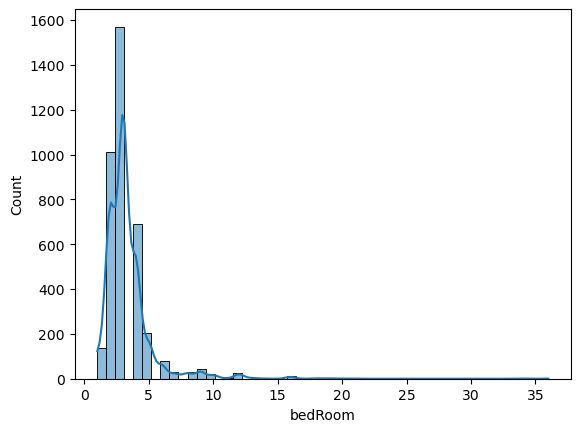

In [66]:
sns.histplot(df['bedRoom'], bins = 50, kde = True)

<Axes: ylabel='bedRoom'>

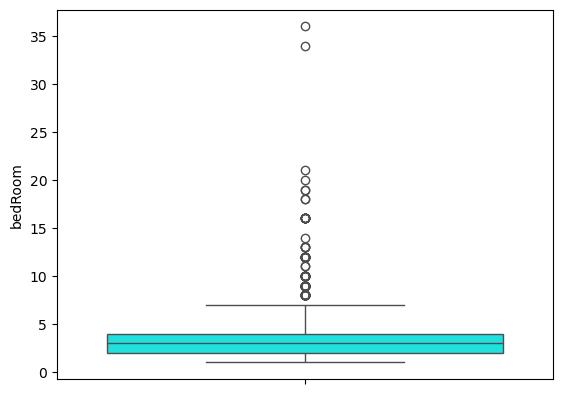

In [68]:
sns.boxplot(df['bedRoom'], color = 'cyan')

In [70]:
df['bedRoom'].describe()

count    3863.000000
mean        3.346622
std         1.998373
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        36.000000
Name: bedRoom, dtype: float64

In [71]:
# Identify potential outliers using IQR method
Q1 = df['bedRoom'].describe()['25%']
Q3 = df['bedRoom'].describe()['75%']
IQR = Q3 - Q1

IQR

2.0

In [72]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound, upper_bound)

-1.0 7.0


In [75]:
df['bedRoom'].isnull().sum()

0

In [80]:
df[df['bedRoom'] <= 5].shape[0] / df.shape[0]

0.9337302614548278

Observations 
* Distribution is right skewed
* Nearly 93% of the properties have bedRooms less the or equal to 5
* There are outlier in the data
* Each property have atleast one bedRoom
* Max rooms are 36(may be some big property)

<h2> bathRoom </h2>

In [82]:
df['bathroom'].isnull().sum()

0

<Axes: xlabel='bathroom'>

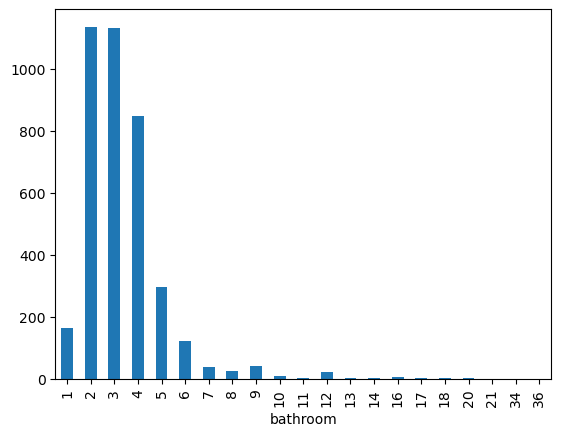

In [87]:
df['bathroom'].value_counts().sort_index().plot(kind='bar')

In [89]:
df['bathroom'].describe()

count    3863.000000
mean        3.402278
std         2.040429
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        36.000000
Name: bathroom, dtype: float64

<Axes: ylabel='proportion'>

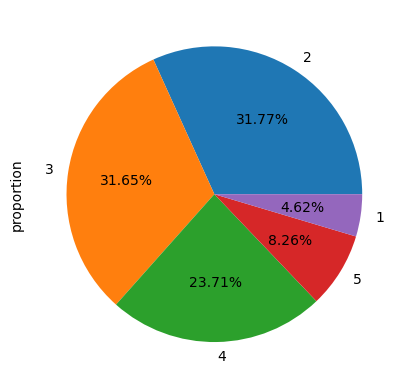

In [90]:
df['bathroom'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

<h2> balcony </h2>

In [95]:
df['balcony'].value_counts()

balcony
3+    1197
3     1124
2      940
1      401
NA     104
0       97
Name: count, dtype: int64

In [94]:
df['balcony'].replace({'No' : 'NA'}, inplace = True)

/tmp/ipykernel_42419/645282172.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['balcony'].replace({'No' : 'NA'}, inplace = True)


<Axes: xlabel='balcony'>

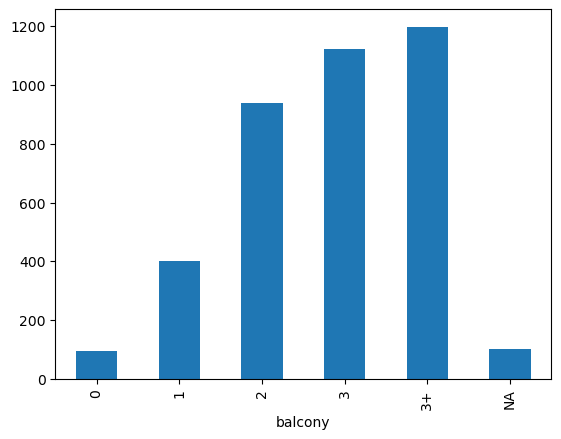

In [98]:
df['balcony'].value_counts().sort_index().plot(kind = 'bar')

<Axes: ylabel='proportion'>

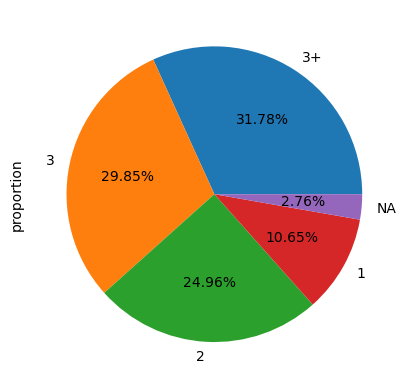

In [99]:
df['balcony'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

<h2> floor number </h2>

<Axes: xlabel='floorNum'>

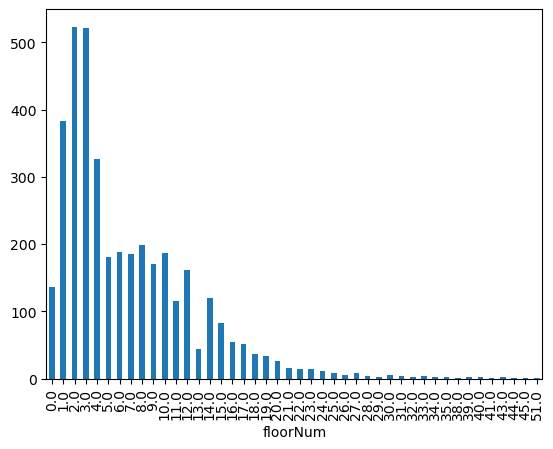

In [104]:

df['floorNum'].value_counts().sort_index().plot(kind = 'bar')

<Axes: xlabel='floor_bin'>

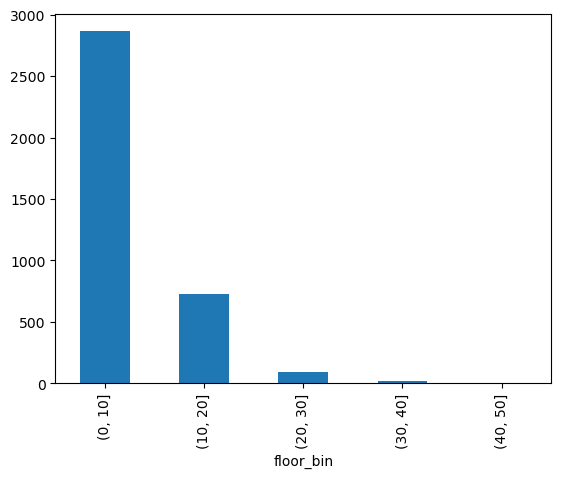

In [105]:
bins = [0, 10, 20, 30, 40, 50]
df['floor_bin'] = pd.cut(df['floorNum'], bins=bins)
df['floor_bin'].value_counts().sort_index().plot(kind='bar')

In [106]:
df['floorNum'].describe()

count    3842.000000
mean        6.767048
std         6.038247
min         0.000000
25%         2.000000
50%         5.000000
75%        10.000000
max        51.000000
Name: floorNum, dtype: float64

In [113]:
df[(df['floorNum'] > 0) & (df['floorNum']<=10)].shape[0] / df['floorNum'].shape[0]

0.7413926999741134

In [114]:
df['floorNum'].isnull().sum()

21

In [116]:
df[df['floorNum'].isnull()]['property_type'].value_counts()

property_type
house    19
flat      2
Name: count, dtype: int64

Observation
* Around 75% of the properties are the range between 1 to 5 floors
* There are 21 null values out of them 19 are houses and 2 are flats

<h2> facing </h2>

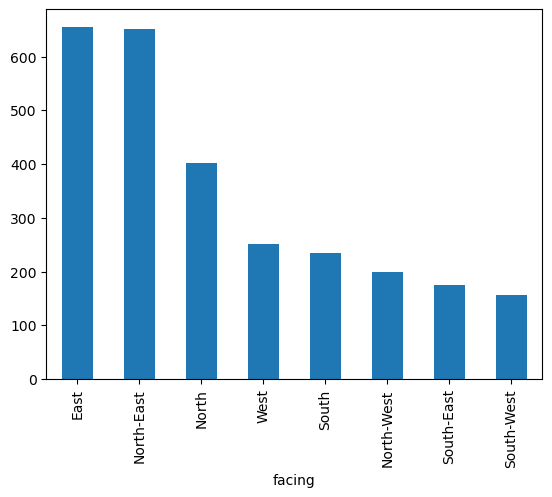

In [122]:
df['facing'].value_counts().plot(kind = 'bar')
plt.show()

In [123]:
df['facing'].describe()

count     2727
unique       8
top       East
freq       655
Name: facing, dtype: object

In [125]:
df['facing'].isnull().sum() # 1136 null values

1136

<h2> agePossession </h2>

In [126]:
df['agePossession'].value_counts()

agePossession
Relatively New        1683
New Property           635
Moderately Old         586
Undefined              348
Old Property           325
Under Construction     286
Name: count, dtype: int64

In [127]:
df['agePossession'].isnull().sum()

0

<h2> areas </h2>

In [132]:
# super_built_up_area	

In [134]:
df['super_built_up_area'].isnull().sum()

1937

In [135]:
df['super_built_up_area'].describe()

count     1926.000000
mean      1918.763006
std        767.294289
min         89.000000
25%       1457.000000
50%       1826.000000
75%       2215.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

<Axes: xlabel='super_built_up_area', ylabel='Count'>

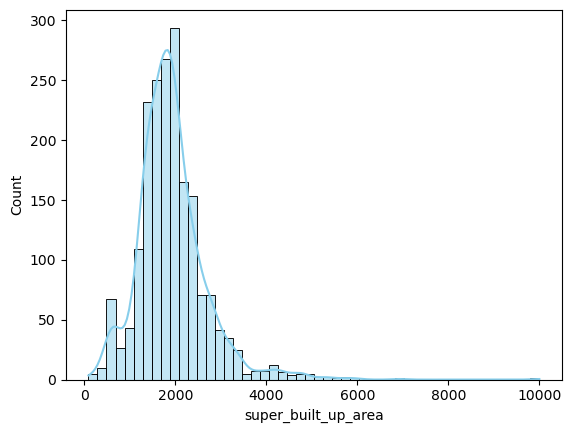

In [136]:
sns.histplot(df['super_built_up_area'].dropna(), bins=50, color='skyblue', kde=True)

<Axes: ylabel='super_built_up_area'>

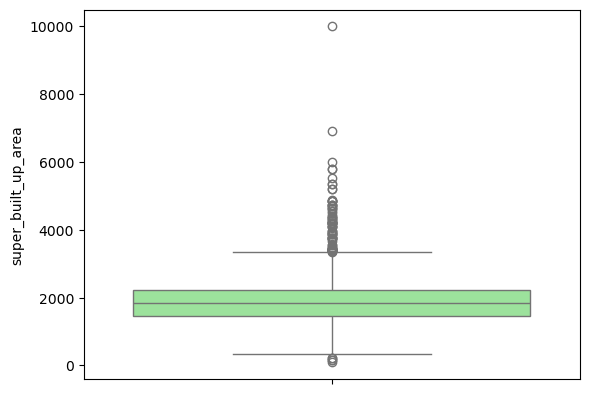

In [137]:
sns.boxplot(df['super_built_up_area'].dropna(), color='lightgreen')

* Most properties have a super built-up area ranging between approximately 1,000 sq.ft and 2,500 sq.ft.
* There are a few properties with a significantly larger area, leading to a right-skewed distribution.
* The interquartile range (IQR) lies between roughly 1,480 sq.ft and 2,215 sq.ft, indicating that the middle 50% of the properties fall * within this range.
* There are several data points beyond the upper "whisker" of the box plot, indicating potential outliers. These are properties with an unusually large super built-up area.

In [138]:
# built_up_area	carpet_area

df['built_up_area'].isnull().sum()

2089

In [139]:
df['built_up_area'].describe()

count      1774.000000
mean       2333.433128
std       17514.699088
min           2.000000
25%        1083.000000
50%        1630.000000
75%        2388.750000
max      737147.000000
Name: built_up_area, dtype: float64

<Axes: xlabel='built_up_area', ylabel='Count'>

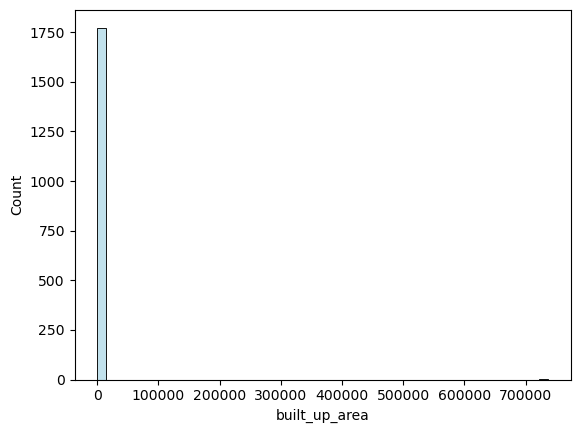

In [145]:
sns.histplot(df['built_up_area'].dropna(), bins = 50,  color = 'lightblue')

<Axes: ylabel='built_up_area'>

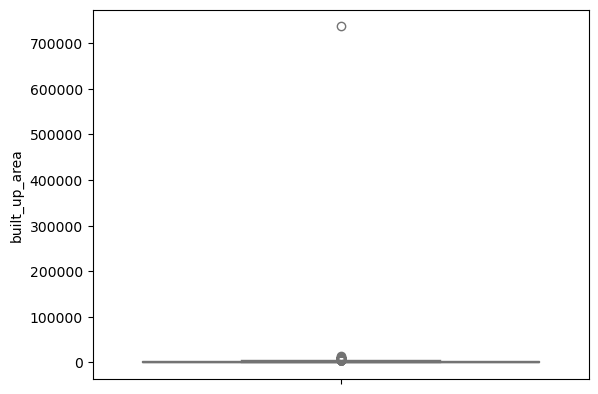

In [146]:
sns.boxplot(df['built_up_area'].dropna(), color='lightgreen')

Observation 
* Most properties have a built-up area ranging roughly between 500 sq.ft and 3,500 sq.ft.
* There are very few properties with a much larger built-up area, leading to a highly right-skewed distribution.
* The box plot confirms the presence of significant outliers on the higher side. The data's interquartile range (IQR) is relatively compact,
but the "whiskers" of the box plot are stretched due to the outliers.
* The presence of extreme values, especially on the higher side, suggests that there may be outliers or data errors.
This could also be due to some properties being exceptionally large, like a commercial complex or an entire building being listed.

In [148]:
df['carpet_area'].isnull().sum()

1888

In [149]:
df['carpet_area'].describe()

count      1975.000000
mean       2463.765523
std       22199.837768
min          15.000000
25%         822.000000
50%        1280.000000
75%        1787.500000
max      607936.000000
Name: carpet_area, dtype: float64

<Axes: xlabel='carpet_area', ylabel='Count'>

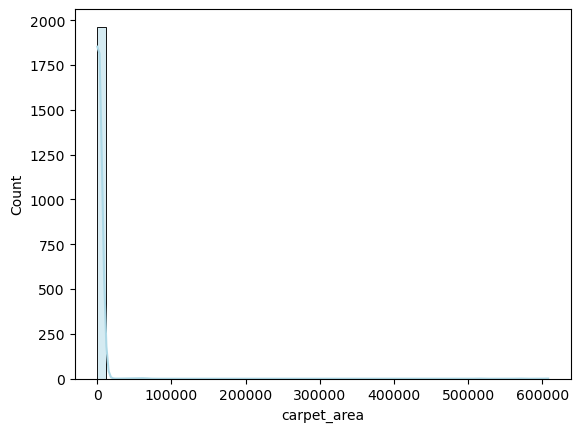

In [153]:
sns.histplot(df['carpet_area'].dropna(),kde = True, bins = 50, color='lightblue')

<Axes: ylabel='carpet_area'>

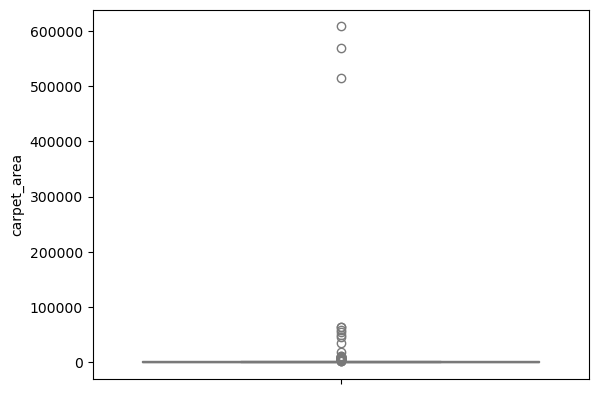

In [154]:
sns.boxplot(df['carpet_area'].dropna(), color='lightblue')

<h2> additionalRooms </h2>

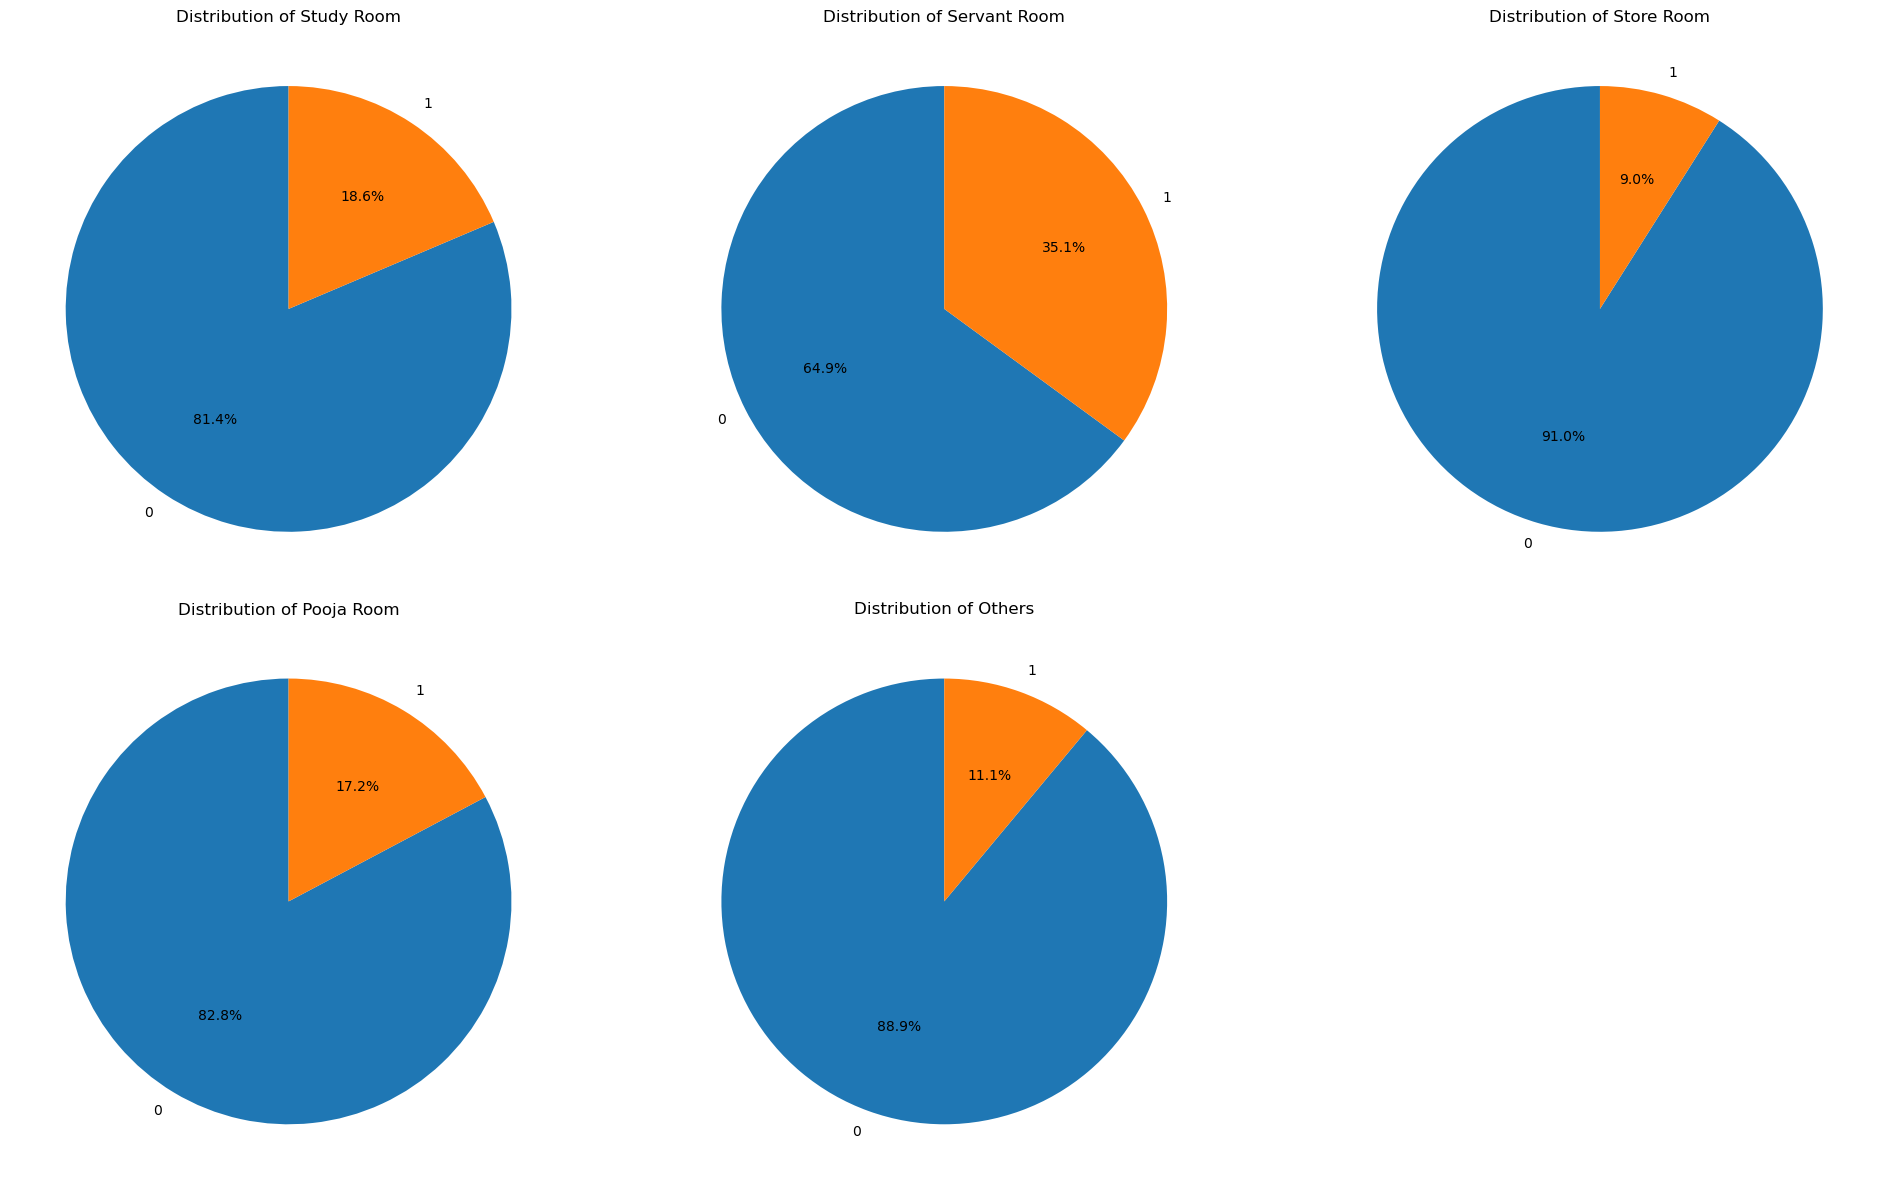

In [157]:
plt.figure(figsize=(20, 12))

# Create a subplot of pie charts for each room type
for idx, room in enumerate(['study room','servant room','store room','pooja room','others'], 1):
    ax = plt.subplot(2, 3, idx)
    df[room].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, ax=ax)
    plt.title(f'Distribution of {room.title()}')
    plt.ylabel('')

plt.tight_layout()
plt.show()

<h2> furnishing type </h2>

<Axes: xlabel='furnishing_type'>

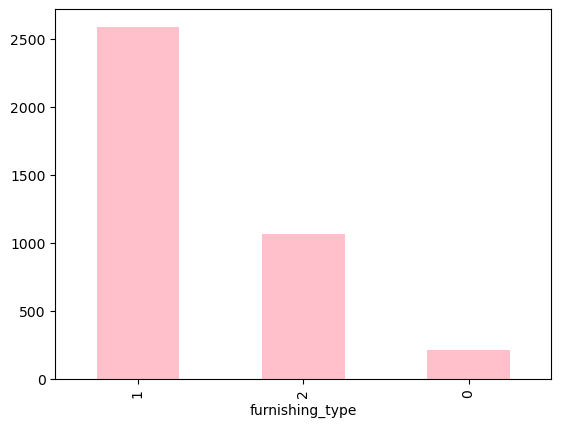

In [159]:
df['furnishing_type'].value_counts().plot(kind = 'bar', color = 'pink')

<Axes: ylabel='count'>

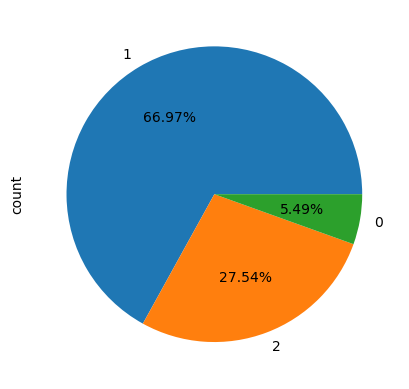

In [161]:
df['furnishing_type'].value_counts().plot(kind='pie',autopct='%0.2f%%')

<h2> luxury score </h2>

In [164]:
df['luxury_score'].isnull().sum()

13

In [165]:
df['luxury_score'].describe()

count    3850.000000
mean       70.067532
std        52.971976
min         0.000000
25%        30.000000
50%        57.000000
75%       108.000000
max       174.000000
Name: luxury_score, dtype: float64

<Axes: xlabel='luxury_score', ylabel='Count'>

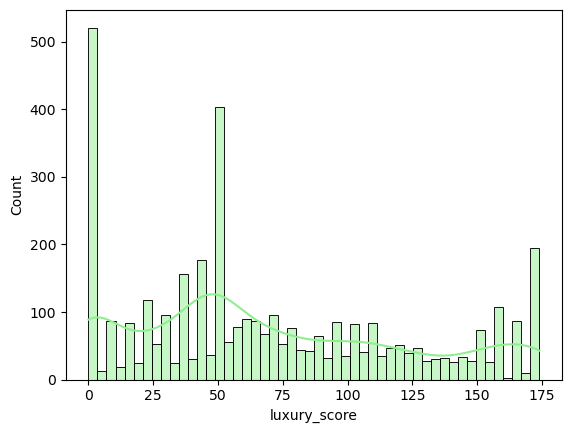

In [167]:
sns.histplot(df['luxury_score'], kde = True, color = 'lightgreen', bins = 50)

<Axes: ylabel='luxury_score'>

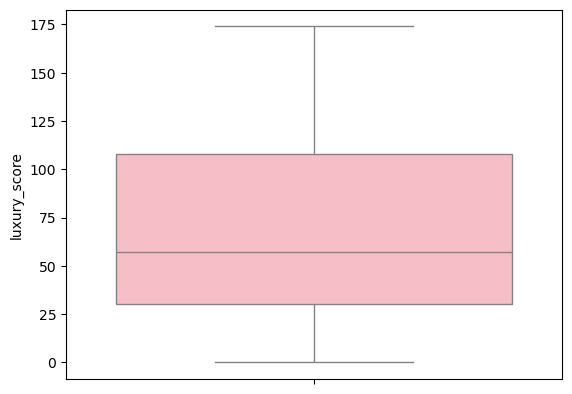

In [169]:
sns.boxplot(df['luxury_score'], color='lightpink')

Observation
* The luxury score distribution has multiple peaks, suggesting a multi-modal distribution. There's a significant number of properties with lower luxury scores (around 0-50), and another peak is observed around the 110-130 range.

* The box plot reveals that the majority of the properties have luxury scores between approximately 30 and 110. The interquartile range (IQR) lies between these values.

In [170]:
df.head()

,property_type,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,floor_bin
0,flat,godrej,1.30,sector 79,8269.0,1572.0,Super Built up area 1572(146.04 sq.m.),2,2,3,3.0,North-East,New Property,1572.0,NaN,NaN,1,0,0,0,0,1,49.0,"(0, 10]"
1,flat,shree vardhman victoria,1.63,sector 70,8358.0,1950.0,Super Built up area 1950(181.16 sq.m.)Carpet area: 1161 sq.ft. (107.86 sq.m.),3,5,3,12.0,East,Relatively New,1950.0,NaN,1161.0,0,1,0,0,0,1,43.0,"(10, 20]"
2,flat,tulip monsella,7.40,sector 53,33198.0,2229.0,Carpet area: 2229 (207.08 sq.m.),4,4,3,21.0,NaN,Under Construction,NaN,NaN,2229.0,0,0,0,0,0,1,35.0,"(20, 30]"
3,flat,raheja sampada,0.65,sector 92,4744.0,1370.0,Super Built up area 1370(127.28 sq.m.),3,2,3,6.0,North-East,Relatively New,1370.0,NaN,NaN,0,0,0,0,0,1,49.0,"(0, 10]"
4,flat,signature andour heights,0.60,sector 71,10000.0,600.0,Super Built up area 600(55.74 sq.m.)Carpet area: 514 sq.ft. (47.75 sq.m.),2,2,1,5.0,South-West,Relatively New,600.0,NaN,514.0,0,0,0,1,0,1,59.0,"(0, 10]"
